In [643]:
import matplotlib.pyplot as plt
import re
from itertools import groupby

In [644]:
kv_pair_regex = re.compile(r'(train_loss|eval rmse|eval mae|learning rate): (\d+\.\d+)')

with open('log_large_100_r2.log', 'r') as log:
    lines = [(match[0][0], float(match[0][1])) for line in log.readlines() if (match := re.findall(kv_pair_regex, line))]

In [645]:
first = lambda pair: pair[0]
sorted_lines = sorted(lines, key=first)
metrics = {k: [v for _, v in g] for k, g in groupby(sorted_lines, first)}

In [646]:
min(metrics['eval rmse']), max(metrics['eval rmse']), len(metrics['eval rmse'])

(2.7128, 3.0665, 101)

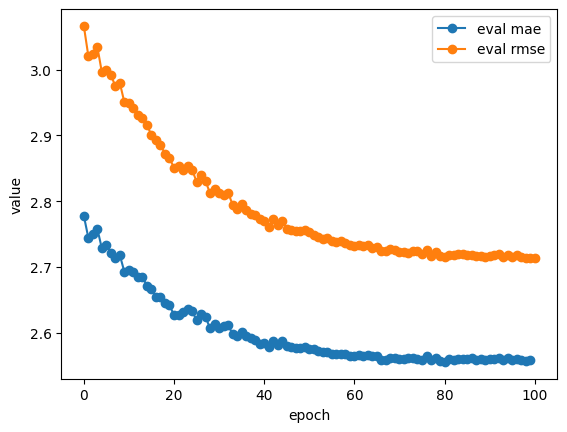

In [647]:
for key, values in [(k,v) for k,v in metrics.items() if 'eval' in k]:
    plt.plot(values, label=key, marker='o')

plt.xlabel('epoch')
plt.ylabel('value')
plt.legend()
plt.show()

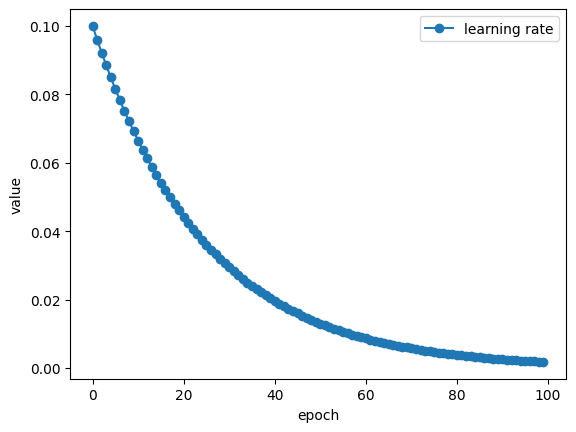

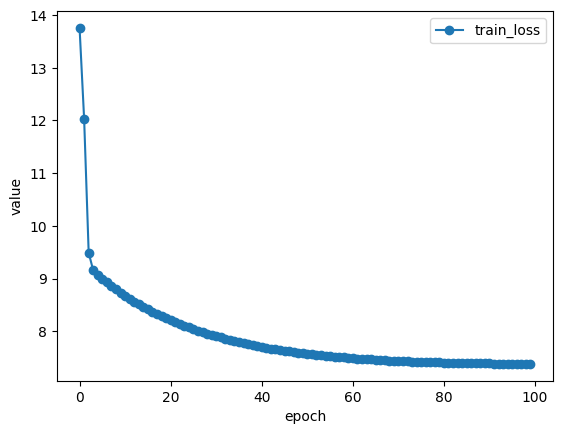

In [648]:
for key, values in [(k,v) for k,v in metrics.items() if 'eval' not in k]:
    plt.plot(values, label=key, marker='o')

    plt.xlabel('epoch')
    plt.ylabel('value')
    plt.legend()
    plt.show()